## Ejercicio Integrador Tema 2: Transformaciones de Datos para Modelos Predictivos
## Alumno: Victor Fernando Michel Juárez

## Ejercicio Integrador

Modulo 2 Tema 2 Transformaciones de Datos para Modelos Predictivos
Fecha de entrega: 31 de mayo 2026
Con la base de datos que vieron en el modulo1 y que se encuentra en Github en la carpeta de Modulo 2 llamada cartera_q1_2026_final.parquet, calcular para cada uno de los ramos de accidentes personales y Gastos médicos:
1.	Calcular estadísticas descriptivas (número de pólizas, prima total, prima promedio, número de siniestros, siniestro promedio, etc.)
2.	Obtener los histogramas de las variables: sexo, edad, año de inicio de vigencia, plan, primas y siniestros. ¿Qué observas?
3.	Codifica las variables que consideres necesario. Explica por qué consideraste esas variables y que tipo de codificación aplicaste.
4.	Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?
5.	Haz la transformación Box-Cox, logarítmica y Yeo-Johnson al monto del siniestro. Haz un histograma de la serie original y cada una de las transformaciones. Agrega la distribución normal.
6.	Crea el Q-Q plot para la serie original y cada transformación, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?
7.	Calcula las siguientes variables derivadas: mayor de 65 años, Siniestros altos (se definen como los montos pagados mayores a $25,000 en accidentes personales y mayores a $200,000 en gastos médicos). ¿Cuántos siniestros cumplen estas características y qué % del total de siniestros representan?
8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan.


## 0. Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import unicodedata

from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_PATH = Path('cartera_q1_2026_final.parquet')

def normalizar_texto(x):
    if pd.isna(x):
        return ''
    texto = str(x).strip().lower()
    texto = ''.join(c for c in unicodedata.normalize('NFKD', texto) if not unicodedata.combining(c))
    return texto

def elegir_columna(df, candidatas, requerido=True):
    disponibles = {normalizar_texto(c): c for c in df.columns}
    for candidata in candidatas:
        llave = normalizar_texto(candidata)
        if llave in disponibles:
            return disponibles[llave]
    if requerido:
        raise KeyError(f'No se encontró ninguna de estas columnas: {candidatas}')
    return None

def stats_serie(serie):
    s = pd.Series(serie).dropna()
    return pd.Series({
        'n': s.shape[0],
        'media': s.mean(),
        'desv_est': s.std(),
        'min': s.min(),
        'p25': s.quantile(0.25),
        'mediana': s.median(),
        'p75': s.quantile(0.75),
        'max': s.max(),
        'asimetria': s.skew(),
        'curtosis': s.kurtosis()
    })

df_raw = pd.read_parquet(DATA_PATH)
print(f'Dimensiones cartera completa: {df_raw.shape[0]:,} filas x {df_raw.shape[1]:,} columnas')
display(df_raw.head())
display(pd.DataFrame({
    'columna': df_raw.columns,
    'tipo': [df_raw[c].dtype for c in df_raw.columns],
    'nulos': [df_raw[c].isna().sum() for c in df_raw.columns],
    'unicos': [df_raw[c].nunique(dropna=True) for c in df_raw.columns]
}))


Dimensiones cartera completa: 50,000 filas x 52 columnas


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,"5,892.42",BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
3,POL-000004,Vid-19-000004,Silvia,Mendoza,Gutierrez,MESG860204IH8,40,M,Soltero,Arquitecto,...,"14,002.67",BAJO,2019,3,1,Premium,Q4,VID,2019,Vida
4,POL-000005,Vid-20-000005,Antonio,Ramos,Castillo,RAAC960722ME2,29,F,Soltero,Independiente,...,"6,545.88",MEDIO,2020,11,4,Premium,Q4,VID,2020,Vida


,columna,tipo,nulos,unicos
0,id_poliza,str,0,50000
1,num_poliza,str,0,50000
2,nombre,category,0,55
3,apellido_paterno,category,0,38
4,apellido_materno,category,0,23
5,rfc,str,0,50000
6,edad,int8,0,46
7,sexo,category,0,2
8,estado_civil,category,0,5
9,ocupacion,category,4000,20


## 1. Selección de ramos y variables base

In [2]:
df = df_raw.copy()

ramo_col = elegir_columna(df, ['ramo'])
id_col = elegir_columna(df, ['id_poliza', 'poliza', 'id'], requerido=False)
sexo_col = elegir_columna(df, ['sexo', 'genero'], requerido=False)
edad_col = elegir_columna(df, ['edad', 'edad_asegurado', 'edad_conductor'])
fecha_col = elegir_columna(df, ['fecha_inicio_vigencia', 'fecha_emision', 'inicio_vigencia', 'fecha_inicio'])
plan_col = elegir_columna(df, ['plan', 'nombre_plan', 'tipo_plan', 'cobertura', 'nivel_riesgo'], requerido=False)
prima_col = elegir_columna(df, ['prima_total', 'prima', 'prima_anual', 'prima_emitida'])
n_siniestros_col = elegir_columna(df, ['n_siniestros', 'num_siniestros', 'numero_siniestros'])
monto_siniestro_col = elegir_columna(df, ['monto_pagado', 'monto_siniestros', 'siniestro', 'monto_siniestro'])

if id_col is None:
    df['id_poliza_codex'] = np.arange(1, len(df) + 1)
    id_col = 'id_poliza_codex'

if sexo_col is None:
    df['sexo_no_disponible'] = 'No disponible'
    sexo_col = 'sexo_no_disponible'

if plan_col is None:
    df['plan_no_disponible'] = 'No disponible'
    plan_col = 'plan_no_disponible'

for col in [edad_col, prima_col, n_siniestros_col, monto_siniestro_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df['anio_inicio_vigencia'] = df[fecha_col].dt.year
df['ramo_texto'] = df[ramo_col].map(normalizar_texto)

mask_ap = df['ramo_texto'].str.contains('accidentes personales', na=False)
mask_gm = df['ramo_texto'].str.contains('gmm|gastos medicos|gastos medico', regex=True, na=False)
df_estudio = df.loc[mask_ap | mask_gm].copy()
df_estudio['ramo_estudio'] = np.select(
    [mask_ap.loc[df_estudio.index], mask_gm.loc[df_estudio.index]],
    ['Accidentes Personales', 'Gastos Médicos'],
    default=df_estudio[ramo_col].astype(str)
)

columnas_base = {
    'ramo': ramo_col,
    'id_poliza': id_col,
    'sexo': sexo_col,
    'edad': edad_col,
    'fecha_inicio_vigencia': fecha_col,
    'plan': plan_col,
    'prima': prima_col,
    'n_siniestros': n_siniestros_col,
    'monto_siniestro': monto_siniestro_col
}

print('Columnas utilizadas:')
display(pd.Series(columnas_base, name='columna_en_archivo'))
print(f'Filas en ramos de estudio: {len(df_estudio):,}')
display(df_estudio['ramo_estudio'].value_counts().rename_axis('ramo').reset_index(name='polizas'))


Columnas utilizadas:


ramo                                      ramo
id_poliza                            id_poliza
sexo                                      sexo
edad                                      edad
fecha_inicio_vigencia    fecha_inicio_vigencia
plan                                      plan
prima                              prima_total
n_siniestros                      n_siniestros
monto_siniestro                   monto_pagado
Name: columna_en_archivo, dtype: str

Filas en ramos de estudio: 27,738


,ramo,polizas
0,Gastos Médicos,22531
1,Accidentes Personales,5207


## 2. Estadísticas descriptivas por ramo

In [3]:
resumen_ramo = (
    df_estudio
    .groupby('ramo_estudio', observed=False)
    .agg(
        polizas=(id_col, 'count'),
        prima_total=(prima_col, 'sum'),
        prima_promedio=(prima_col, 'mean'),
        prima_mediana=(prima_col, 'median'),
        siniestros=(n_siniestros_col, 'sum'),
        polizas_con_siniestro=(n_siniestros_col, lambda s: (s.fillna(0) > 0).sum()),
        monto_pagado_total=(monto_siniestro_col, 'sum'),
        monto_pagado_promedio_poliza=(monto_siniestro_col, 'mean'),
        monto_pagado_mediano_poliza=(monto_siniestro_col, 'median'),
        edad_promedio=(edad_col, 'mean'),
        edad_mediana=(edad_col, 'median')
    )
)

resumen_ramo['frecuencia_siniestros'] = resumen_ramo['siniestros'] / resumen_ramo['polizas']
resumen_ramo['siniestro_promedio_por_siniestro'] = resumen_ramo['monto_pagado_total'] / resumen_ramo['siniestros'].replace(0, np.nan)
resumen_ramo['loss_ratio'] = resumen_ramo['monto_pagado_total'] / resumen_ramo['prima_total'].replace(0, np.nan)

display(resumen_ramo.round(2))

resumen_numerico = (
    df_estudio
    .groupby('ramo_estudio', observed=False)[[edad_col, prima_col, n_siniestros_col, monto_siniestro_col]]
    .describe()
    .round(2)
)
display(resumen_numerico)


,polizas,prima_total,prima_promedio,prima_mediana,siniestros,polizas_con_siniestro,monto_pagado_total,monto_pagado_promedio_poliza,monto_pagado_mediano_poliza,edad_promedio,edad_mediana,frecuencia_siniestros,siniestro_promedio_por_siniestro,loss_ratio
ramo_estudio,,,,,,,,,,,,,,
Accidentes Personales,5207,"24,980,678.88","4,797.52","4,301.28","1,833.00",1541,"22,311,397.14","4,284.89",0.00,43.49,44.00,0.35,"12,172.07",0.89
Gastos Médicos,22531,"731,022,322.30","32,445.18","22,049.28","8,146.00",6845,"96,912,286.07","4,301.29",0.00,43.30,43.00,0.36,"11,896.92",0.13


edad                                            \
                          count  mean   std   min   25%   50%   75%   max   
ramo_estudio                                                                
Accidentes Personales  5,207.00 43.49 12.79 21.00 32.00 44.00 54.00 66.00   
Gastos Médicos        22,531.00 43.30 12.97 21.00 32.00 43.00 54.00 66.00   

                      prima_total            ... n_siniestros       \
                            count      mean  ...          75%  max   
ramo_estudio                                 ...                     
Accidentes Personales    5,207.00  4,797.52  ...         1.00 4.00   
Gastos Médicos          22,531.00 32,445.18  ...         1.00 4.00   

                      monto_pagado                                         \
                             count     mean       std  min  25%  50%  75%   
ramo_estudio                                                                
Accidentes Personales     5,207.00 4,284.89 25,761.29 0.00 0.00 0.00 0.00   
Gastos Médicos           22,531.00 4,301.29 20,609.64 0.00 0.00 0.00 0.00   

                                    
                               max  
ramo_estudio                        
Accidentes Personales 1,067,933.83  
Gastos Médicos          698,744.32  

[2 rows x 32 columns]

**MARCA_CONCLUSION_DESCRIPTIVAS**

En esta sección revisaría la diferencia de tamaño entre los dos ramos, la concentración de prima y el comportamiento de la siniestralidad. Si un ramo concentra mucho monto pagado con pocas pólizas o pocos siniestros, eso sugiere severidad alta y una distribución con cola pesada. También compararía la prima promedio contra la mediana para detectar si la cartera está influida por pólizas grandes.

## 3. Histogramas y distribuciones solicitadas

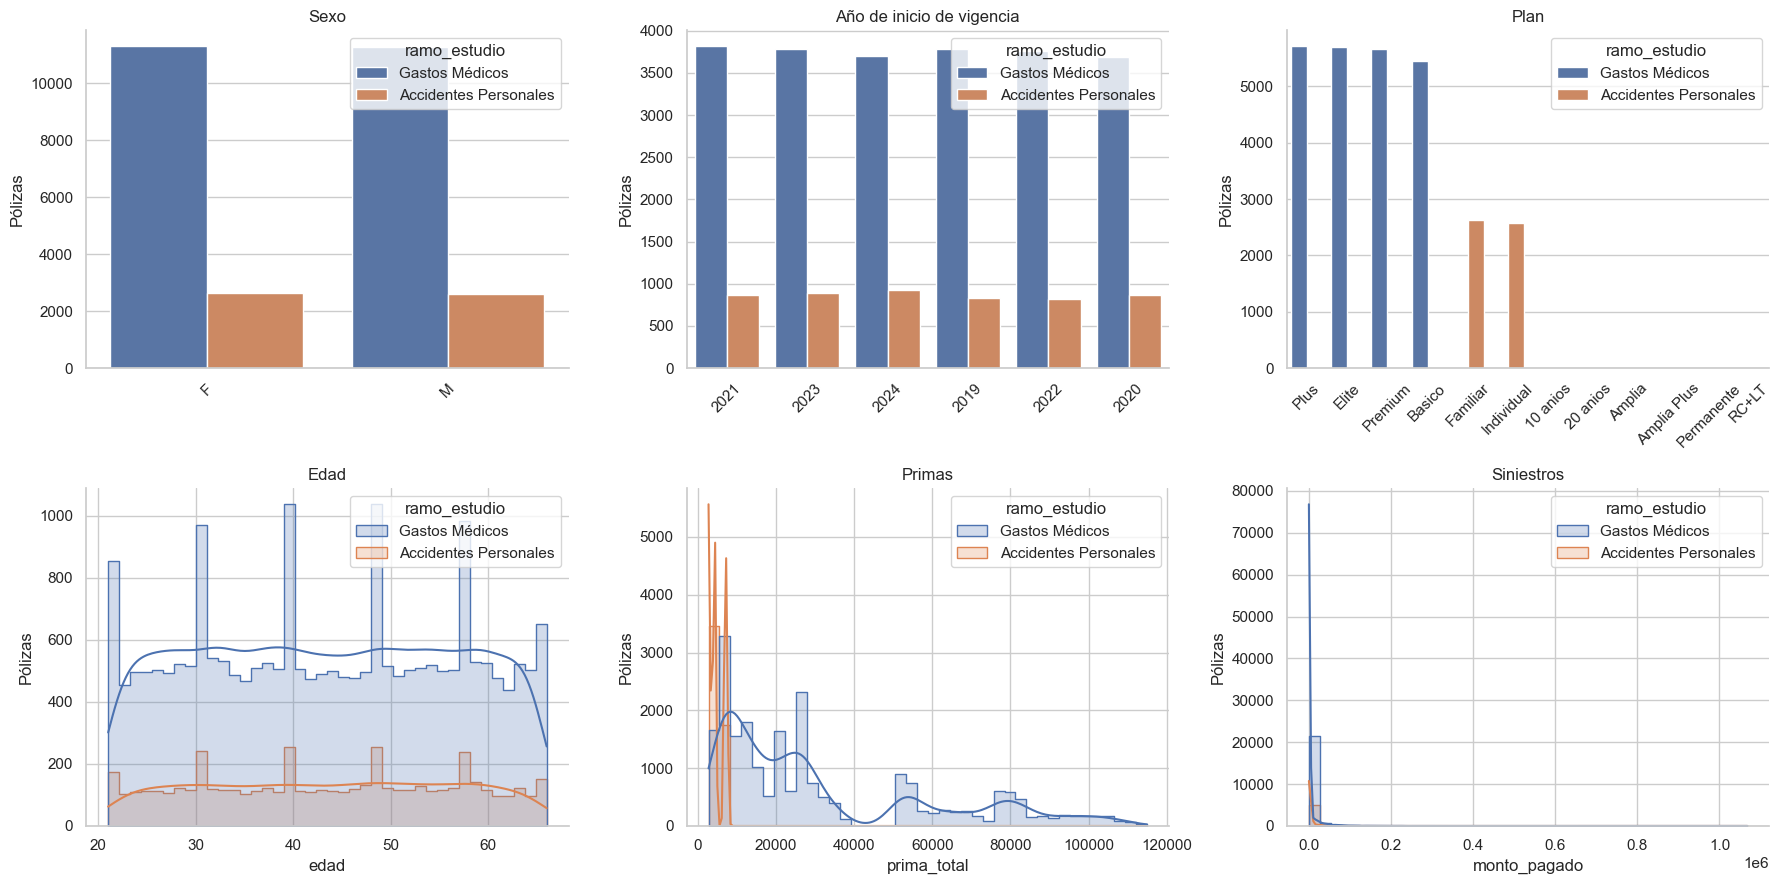

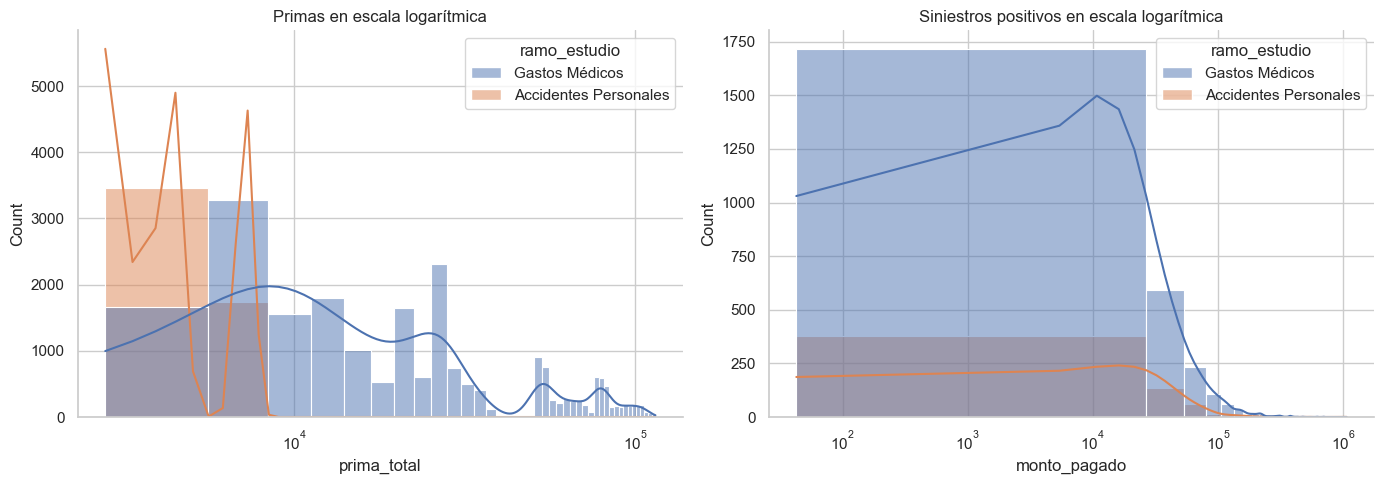

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

categoricas = [
    (sexo_col, 'Sexo'),
    ('anio_inicio_vigencia', 'Año de inicio de vigencia'),
    (plan_col, 'Plan')
]

for ax, (col, titulo) in zip(axes[:3], categoricas):
    orden = df_estudio[col].value_counts().head(12).index
    sns.countplot(data=df_estudio, x=col, hue='ramo_estudio', order=orden, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel('Pólizas')
    ax.tick_params(axis='x', rotation=45)

numericas = [
    (edad_col, 'Edad'),
    (prima_col, 'Primas'),
    (monto_siniestro_col, 'Siniestros')
]

for ax, (col, titulo) in zip(axes[3:], numericas):
    sns.histplot(data=df_estudio, x=col, hue='ramo_estudio', bins=40, kde=True, element='step', stat='count', common_norm=False, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_ylabel('Pólizas')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_estudio[df_estudio[prima_col] > 0], x=prima_col, hue='ramo_estudio', bins=40, kde=True, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Primas en escala logarítmica')

sns.histplot(data=df_estudio[df_estudio[monto_siniestro_col] > 0], x=monto_siniestro_col, hue='ramo_estudio', bins=40, kde=True, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Siniestros positivos en escala logarítmica')

plt.tight_layout()
plt.show()


**MARCA_CONCLUSION_HISTOGRAMAS**

Las variables categóricas sirven para ver composición de cartera: sexo, año y plan pueden mostrar si un ramo está más concentrado que el otro. En las variables monetarias espero observar asimetría positiva: muchas pólizas con prima o siniestro bajo y pocos valores muy altos. Por eso también conviene revisar primas y siniestros positivos en escala logarítmica.

## 4. Codificación de variables

In [5]:
df_modelo = df_estudio.copy()

sexo_limpio = df_modelo[sexo_col].astype(str).map(normalizar_texto)
valores_sexo = sorted(sexo_limpio.dropna().unique())

if len(valores_sexo) == 2:
    mapa_sexo = {valores_sexo[0]: 0, valores_sexo[1]: 1}
    df_modelo['sexo_codificado'] = sexo_limpio.map(mapa_sexo)
else:
    df_modelo['sexo_codificado'] = pd.factorize(sexo_limpio)[0]
    mapa_sexo = 'factorize'

df_modelo['ramo_gastos_medicos'] = (df_modelo['ramo_estudio'] == 'Gastos Médicos').astype(int)
df_modelo['mayor_65'] = (df_modelo[edad_col] >= 65).astype(int)
df_modelo['anio_inicio_vigencia_num'] = df_modelo['anio_inicio_vigencia']

dummies_plan = pd.get_dummies(df_modelo[plan_col].astype(str), prefix='plan', dtype=int)
df_modelo = pd.concat([df_modelo, dummies_plan], axis=1)

columnas_codificadas = ['sexo_codificado', 'ramo_gastos_medicos', 'mayor_65', 'anio_inicio_vigencia_num'] + dummies_plan.columns.tolist()

print('Mapa sexo:')
print(mapa_sexo)
print('\nColumnas codificadas:')
display(pd.Series(columnas_codificadas, name='variable'))
display(df_modelo[columnas_codificadas].head())


Mapa sexo:
{'f': 0, 'm': 1}

Columnas codificadas:


0             sexo_codificado
1         ramo_gastos_medicos
2                    mayor_65
3    anio_inicio_vigencia_num
4                 plan_Basico
5                  plan_Elite
6               plan_Familiar
7             plan_Individual
8                   plan_Plus
9                plan_Premium
Name: variable, dtype: str

,sexo_codificado,ramo_gastos_medicos,mayor_65,anio_inicio_vigencia_num,plan_Basico,plan_Elite,plan_Familiar,plan_Individual,plan_Plus,plan_Premium
2,1,1,0,2022,1,0,0,0,0,0
6,1,1,0,2023,0,0,0,0,1,0
7,1,1,0,2019,0,0,0,0,1,0
8,1,1,0,2024,0,1,0,0,0,0
10,0,1,0,2023,0,0,0,0,0,1


**MARCA_CONCLUSION_CODIFICACION**

Codifiqué sexo como variable binaria cuando existen dos categorías, ramo como indicador binario porque el análisis se limita a dos ramos, mayor de 65 como dummy actuarial de riesgo y año de inicio como variable numérica temporal. Para plan usé one-hot encoding porque es una variable nominal: no conviene imponer un orden artificial entre planes.

## 5. Escalamiento de primas y siniestros

n     media  desv_est      min      p25   mediana  \
variable  escala                                                               
prima     original 27,738.00 27,255.14 27,780.17 2,784.00 6,960.00 15,056.80   
          z_score  27,738.00      0.00      1.00    -0.88    -0.73     -0.44   
          min_max  27,738.00      0.22      0.25     0.00     0.04      0.11   
          robust   27,738.00      0.46      1.04    -0.46    -0.30      0.00   
siniestro original 27,738.00  4,298.21 21,669.77     0.00     0.00      0.00   
          z_score  27,738.00     -0.00      1.00    -0.20    -0.20     -0.20   
          min_max  27,738.00      0.00      0.02     0.00     0.00      0.00   
          robust   27,738.00  4,298.21 21,669.77     0.00     0.00      0.00   

                         p75          max  asimetria  curtosis  
variable  escala                                                
prima     original 33,558.80   114,931.87       1.31      0.57  
          z_score       0.23         3.16       1.31      0.57  
          min_max       0.27         1.00       1.31      0.57  
          robust        0.70         3.75       1.31      0.57  
siniestro original      0.00 1,067,933.83      14.06    377.63  
          z_score      -0.20        49.08      14.06    377.63  
          min_max       0.00         1.00      14.06    377.63  
          robust        0.00 1,067,933.83      14.06    377.63

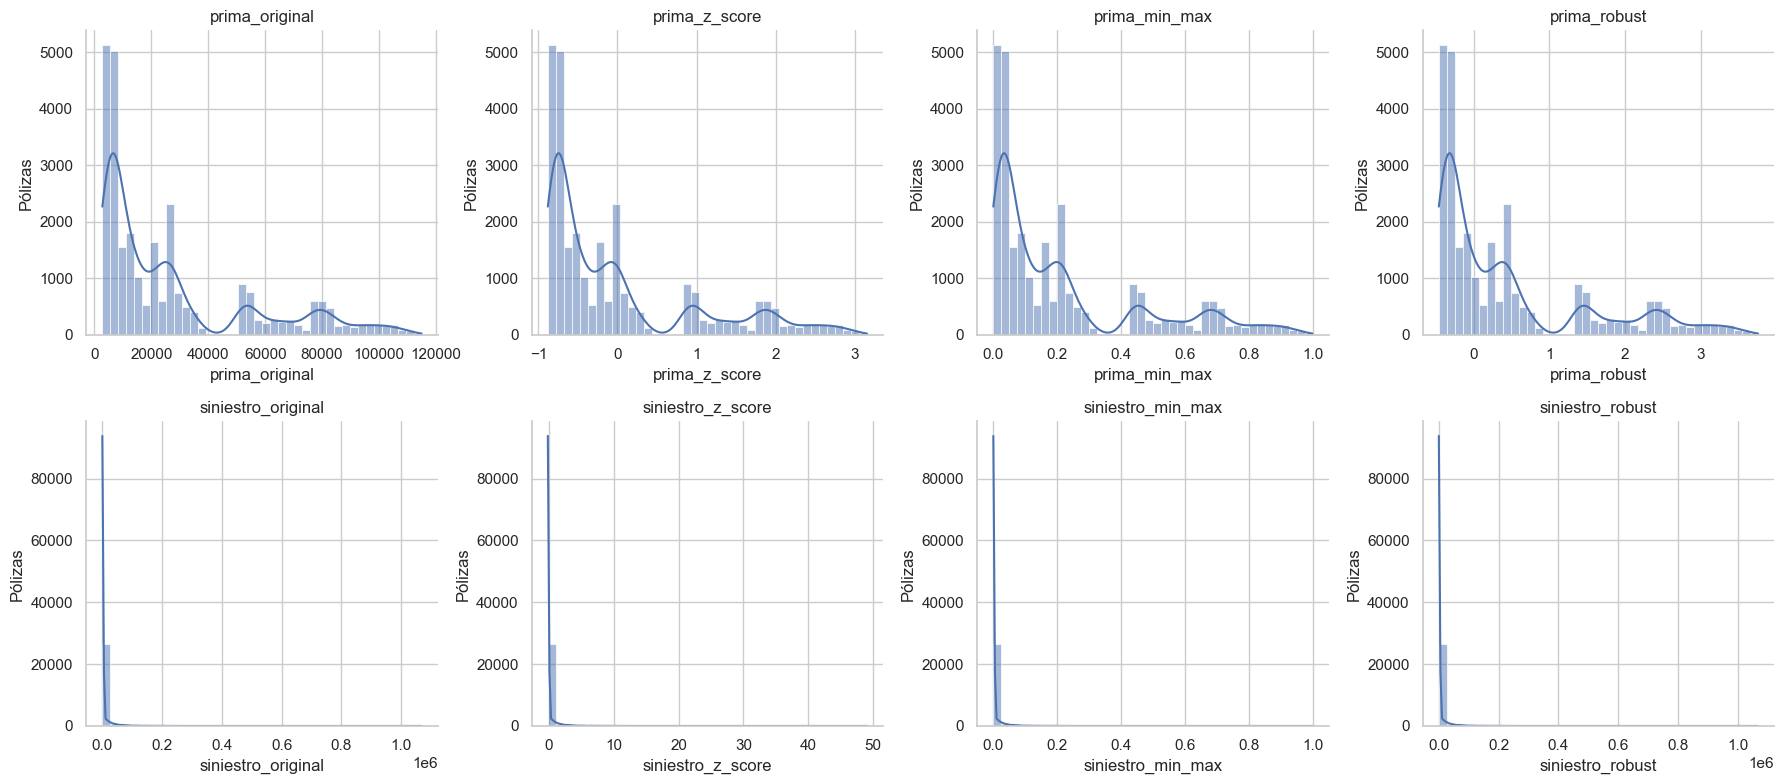

In [6]:
variables_escalar = {
    'prima': prima_col,
    'siniestro': monto_siniestro_col
}

scalers = {
    'z_score': StandardScaler(),
    'min_max': MinMaxScaler(),
    'robust': RobustScaler()
}

df_escalado = df_estudio.copy()
tablas_stats = []

for nombre_variable, col in variables_escalar.items():
    x = df_escalado[[col]].fillna(0).astype(float)
    df_escalado[f'{nombre_variable}_original'] = x[col]
    tablas_stats.append(stats_serie(df_escalado[f'{nombre_variable}_original']).rename((nombre_variable, 'original')))
    for nombre_scaler, scaler in scalers.items():
        nueva_col = f'{nombre_variable}_{nombre_scaler}'
        df_escalado[nueva_col] = scaler.fit_transform(x).ravel()
        tablas_stats.append(stats_serie(df_escalado[nueva_col]).rename((nombre_variable, nombre_scaler)))

stats_escalamiento = pd.DataFrame(tablas_stats)
stats_escalamiento.index = pd.MultiIndex.from_tuples(stats_escalamiento.index, names=['variable', 'escala'])

display(stats_escalamiento.round(4))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for fila, nombre_variable in enumerate(variables_escalar):
    cols = [
        f'{nombre_variable}_original',
        f'{nombre_variable}_z_score',
        f'{nombre_variable}_min_max',
        f'{nombre_variable}_robust'
    ]
    for ax, col in zip(axes[fila], cols):
        sns.histplot(df_escalado[col].dropna(), bins=40, kde=True, ax=ax)
        ax.set_title(col)
        ax.set_ylabel('Pólizas')

plt.tight_layout()
plt.show()


**MARCA_CONCLUSION_ESCALAMIENTO**

El escalamiento cambia la escala, pero no elimina la asimetría ni los valores extremos. Z-score centra en media cero y desviación estándar uno, Min-Max comprime todo al intervalo 0-1 y RobustScaler usa mediana e IQR, por lo que suele ser más estable cuando primas y siniestros tienen colas pesadas.

## 6. Transformaciones Box-Cox, logarítmica y Yeo-Johnson sobre siniestros

Siniestros positivos: 3,436
Lambda Box-Cox: 0.1364
Lambda Yeo-Johnson: 0.1362


,n,media,desv_est,min,p25,mediana,p75,max,asimetria,curtosis
original,"3,436.00","34,698.39","52,312.72",42.60,"8,127.82","19,209.66","41,017.36","1,067,933.83",6.14,71.20
log,"3,436.00",9.75,1.30,3.75,9.00,9.86,10.62,13.88,-0.63,1.02
box_cox,"3,436.00",20.81,4.79,4.90,17.70,20.81,23.88,41.35,0.02,0.35
yeo_johnson,"3,436.00",20.78,4.78,4.94,17.68,20.79,23.85,41.28,0.02,0.35


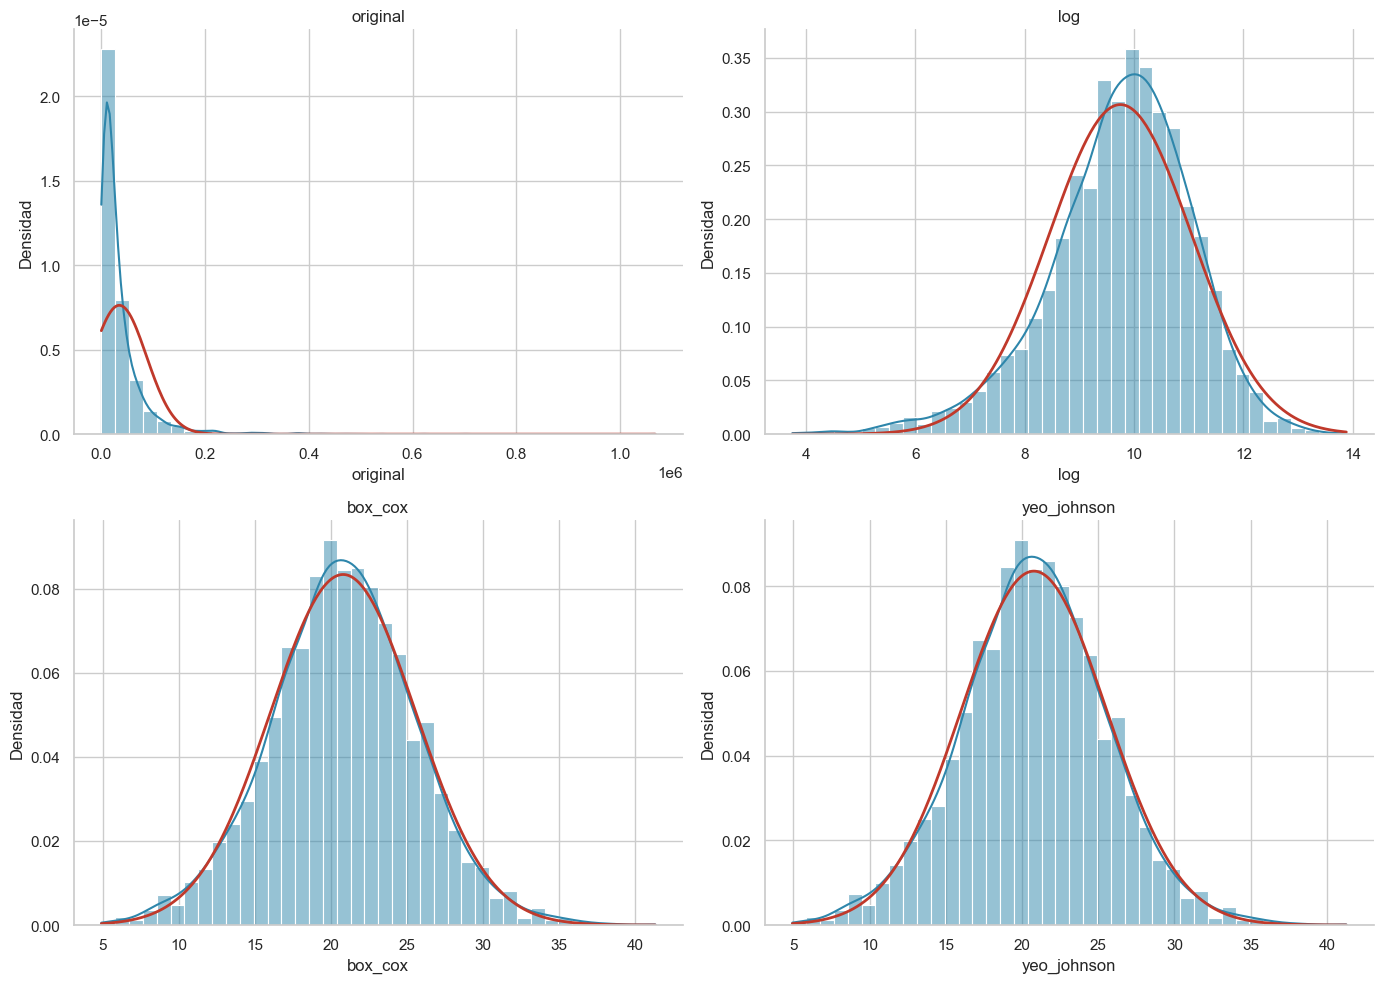

In [7]:
df_siniestros = df_estudio.loc[
    (df_estudio[n_siniestros_col].fillna(0) > 0) &
    (df_estudio[monto_siniestro_col].fillna(0) > 0)
].copy()

serie_siniestro = df_siniestros[monto_siniestro_col].astype(float)

boxcox_vals, lambda_boxcox = stats.boxcox(serie_siniestro)
yeojohnson_vals, lambda_yeojohnson = stats.yeojohnson(serie_siniestro)

df_transformaciones = pd.DataFrame({
    'original': serie_siniestro.values,
    'log': np.log(serie_siniestro.values),
    'box_cox': boxcox_vals,
    'yeo_johnson': yeojohnson_vals
})

print(f'Siniestros positivos: {len(df_transformaciones):,}')
print(f'Lambda Box-Cox: {lambda_boxcox:.4f}')
print(f'Lambda Yeo-Johnson: {lambda_yeojohnson:.4f}')

display(df_transformaciones.apply(stats_serie).T.round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, df_transformaciones.columns):
    data = df_transformaciones[col].dropna()
    sns.histplot(data, bins=40, stat='density', kde=True, color='#2E86AB', ax=ax)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, stats.norm.pdf(x, data.mean(), data.std()), color='#C0392B', lw=2)
    ax.set_title(col)
    ax.set_ylabel('Densidad')

plt.tight_layout()
plt.show()


**MARCA_CONCLUSION_TRANSFORMACIONES**

Las transformaciones reducen la asimetría del monto de siniestro, pero no necesariamente lo vuelven normal. Box-Cox solo puede aplicarse a montos positivos; log también requiere trabajar con positivos o usar log1p si se incluyen ceros; Yeo-Johnson es más flexible porque admite cero y valores no positivos. Para severidades, la transformación suele mejorar visualización y modelado, aunque la interpretación monetaria debe regresar con cuidado a la escala original.

## 7. Q-Q plots y pruebas de normalidad

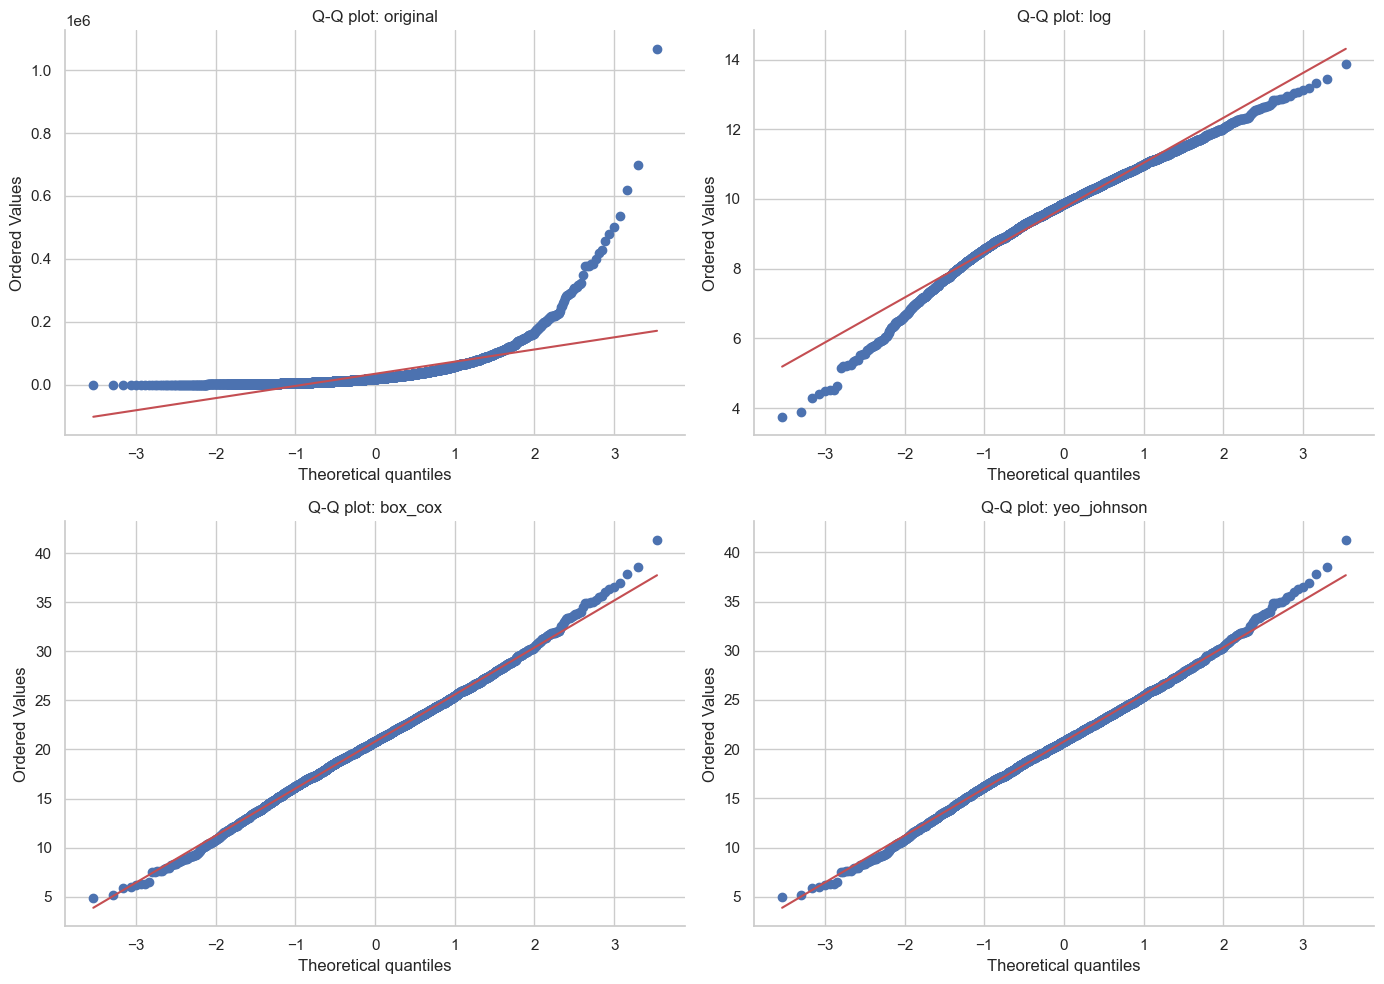

,serie,n,normaltest_k2,normaltest_p,shapiro_stat,shapiro_p,decision_5pct
0,original,3436,"4,105.85",0.00,0.55,0.00,Rechaza normalidad
1,log,3436,262.90,0.00,0.98,0.00,Rechaza normalidad
2,box_cox,3436,13.36,0.00,1.00,0.00,Rechaza normalidad
3,yeo_johnson,3436,13.26,0.00,1.00,0.00,Rechaza normalidad


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

resultados_normalidad = []

for ax, col in zip(axes, df_transformaciones.columns):
    data = df_transformaciones[col].dropna()
    stats.probplot(data, dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot: {col}')

    if len(data) >= 8:
        k2, p_normaltest = stats.normaltest(data)
    else:
        k2, p_normaltest = np.nan, np.nan

    muestra_shapiro = data.sample(min(len(data), 5000), random_state=42) if len(data) > 5000 else data
    if len(muestra_shapiro) >= 3:
        shapiro_stat, p_shapiro = stats.shapiro(muestra_shapiro)
    else:
        shapiro_stat, p_shapiro = np.nan, np.nan

    resultados_normalidad.append({
        'serie': col,
        'n': len(data),
        'normaltest_k2': k2,
        'normaltest_p': p_normaltest,
        'shapiro_stat': shapiro_stat,
        'shapiro_p': p_shapiro,
        'decision_5pct': 'No rechaza normalidad' if p_normaltest >= 0.05 else 'Rechaza normalidad'
    })

plt.tight_layout()
plt.show()

tabla_normalidad = pd.DataFrame(resultados_normalidad)
display(tabla_normalidad.round(6))


**MARCA_CONCLUSION_NORMALIDAD**

El Q-Q plot permite ver si las colas se acercan a una normal. La prueba de hipótesis contrasta normalidad: si el p-value es menor a 0.05, se rechaza normalidad. En datos de siniestros es común que incluso después de transformar se rechace normalidad, porque la severidad suele mantener colas pesadas y observaciones extremas.

## 8. Variables derivadas: mayor de 65 y siniestros altos

In [9]:
df_derivadas = df_estudio.copy()
df_derivadas['mayor_65'] = (df_derivadas[edad_col] >= 65).astype(int)
df_derivadas['umbral_siniestro_alto'] = np.where(
    df_derivadas['ramo_estudio'].eq('Accidentes Personales'),
    25_000,
    200_000
)
df_derivadas['siniestro_alto'] = (
    (df_derivadas[n_siniestros_col].fillna(0) > 0) &
    (df_derivadas[monto_siniestro_col].fillna(0) > df_derivadas['umbral_siniestro_alto'])
).astype(int)

total_siniestros_ramo = df_derivadas.groupby('ramo_estudio')[n_siniestros_col].sum()

resumen_derivadas = (
    df_derivadas
    .groupby('ramo_estudio', observed=False)
    .agg(
        polizas=(id_col, 'count'),
        polizas_mayor_65=('mayor_65', 'sum'),
        siniestros_total=(n_siniestros_col, 'sum'),
        siniestros_en_mayor_65=(n_siniestros_col, lambda s: s[df_derivadas.loc[s.index, 'mayor_65'].eq(1)].sum()),
        polizas_con_siniestro_alto=('siniestro_alto', 'sum'),
        siniestros_en_polizas_con_siniestro_alto=(n_siniestros_col, lambda s: s[df_derivadas.loc[s.index, 'siniestro_alto'].eq(1)].sum()),
        monto_pagado_siniestros_altos=(monto_siniestro_col, lambda s: s[df_derivadas.loc[s.index, 'siniestro_alto'].eq(1)].sum())
    )
)

resumen_derivadas['pct_siniestros_mayor_65'] = resumen_derivadas['siniestros_en_mayor_65'] / resumen_derivadas['siniestros_total'].replace(0, np.nan)
resumen_derivadas['pct_siniestros_altos'] = resumen_derivadas['siniestros_en_polizas_con_siniestro_alto'] / resumen_derivadas['siniestros_total'].replace(0, np.nan)
resumen_derivadas['pct_polizas_mayor_65'] = resumen_derivadas['polizas_mayor_65'] / resumen_derivadas['polizas'].replace(0, np.nan)

display(resumen_derivadas.round(4))

display(
    df_derivadas.loc[df_derivadas['siniestro_alto'].eq(1),
                     ['ramo_estudio', id_col, edad_col, sexo_col, plan_col, n_siniestros_col, monto_siniestro_col, 'umbral_siniestro_alto']]
    .sort_values(['ramo_estudio', monto_siniestro_col], ascending=[True, False])
    .head(20)
)


,polizas,polizas_mayor_65,siniestros_total,siniestros_en_mayor_65,polizas_con_siniestro_alto,siniestros_en_polizas_con_siniestro_alto,monto_pagado_siniestros_altos,pct_siniestros_mayor_65,pct_siniestros_altos,pct_polizas_mayor_65
ramo_estudio,,,,,,,,,,
Accidentes Personales,5207,151,"1,833.00",70.00,263,376.00,"18,497,600.40",0.04,0.21,0.03
Gastos Médicos,22531,650,"8,146.00",258.00,45,67.00,"13,359,460.75",0.03,0.01,0.03


,ramo_estudio,id_poliza,edad,sexo,plan,n_siniestros,monto_pagado,umbral_siniestro_alto
8824,Accidentes Personales,POL-008825,61,F,Familiar,3.00,"1,067,933.83",25000
1070,Accidentes Personales,POL-001071,39,F,Individual,1.00,"536,011.86",25000
13283,Accidentes Personales,POL-013284,26,F,Individual,1.00,"500,836.56",25000
43751,Accidentes Personales,POL-043752,64,M,Familiar,1.00,"457,859.82",25000
10161,Accidentes Personales,POL-010162,43,F,Individual,2.00,"418,614.60",25000
31097,Accidentes Personales,POL-031098,36,M,Individual,1.00,"289,579.74",25000
1701,Accidentes Personales,POL-001702,63,F,Familiar,1.00,"285,716.14",25000
11806,Accidentes Personales,POL-011807,46,F,Individual,2.00,"280,514.52",25000
44154,Accidentes Personales,POL-044155,52,F,Familiar,1.00,"217,832.70",25000
25663,Accidentes Personales,POL-025664,58,M,Individual,1.00,"206,198.71",25000


**MARCA_CONCLUSION_DERIVADAS**

La variable mayor de 65 separa un segmento etario relevante para riesgo y severidad. La variable siniestro alto usa umbrales distintos por ramo porque Accidentes Personales y Gastos Médicos no tienen la misma escala de severidad. El porcentaje debe leerse contra el total de siniestros del ramo, no contra toda la cartera, para que la comparación sea justa.

## 9. Media del siniestro por sexo, año de inicio de vigencia y plan

polizas_con_siniestro  siniestros  monto_promedio  \
ramo_estudio          sexo                                                      
Accidentes Personales F                       314      411.00       40,646.31   
                      M                       309      408.00       30,901.15   
Gastos Médicos        F                      1467    1,886.00       34,451.01   
                      M                      1346    1,745.00       34,452.19   

                            monto_mediano  
ramo_estudio          sexo                 
Accidentes Personales F         18,729.02  
                      M         19,096.89  
Gastos Médicos        F         19,317.58  
                      M         19,558.50

polizas_con_siniestro  siniestros  \
ramo_estudio          anio_inicio_vigencia                                      
Accidentes Personales 2019                                     98      123.00   
                      2020                                    110      150.00   
                      2021                                    105      136.00   
                      2022                                     96      129.00   
                      2023                                     91      123.00   
                      2024                                    123      158.00   
Gastos Médicos        2019                                    442      565.00   
                      2020                                    471      595.00   
                      2021                                    484      636.00   
                      2022                                    490      624.00   
                      2023                                    496      652.00   
                      2024                                    430      559.00   

                                            monto_promedio  monto_mediano  
ramo_estudio          anio_inicio_vigencia                                 
Accidentes Personales 2019                       30,474.39      20,123.54  
                      2020                       39,519.25      18,518.18  
                      2021                       40,224.64      21,192.41  
                      2022                       38,292.05      18,729.02  
                      2023                       36,055.92      19,525.95  
                      2024                       30,870.54      16,926.90  
Gastos Médicos        2019                       34,399.88      20,338.02  
                      2020                       34,667.67      19,511.26  
                      2021                       33,620.49      19,155.86  
                      2022                       35,195.41      21,288.48  
                      2023                       35,001.74      17,583.64  
                      2024                       33,721.24      16,985.09

polizas_con_siniestro  siniestros  \
ramo_estudio          plan                                             
Accidentes Personales Individual                     305      391.00   
                      Familiar                       318      428.00   
                      10 anios                         0        0.00   
                      20 anios                         0        0.00   
                      Amplia                           0        0.00   
                      Amplia Plus                      0        0.00   
                      Basico                           0        0.00   
                      Elite                            0        0.00   
                      Permanente                       0        0.00   
                      Plus                             0        0.00   
                      Premium                          0        0.00   
                      RC+LT                            0        0.00   
Gastos Médicos        Plus                           709      926.00   
                      Elite                          708      892.00   
                      Basico                         683      891.00   
                      Premium                        713      922.00   
                      10 anios                         0        0.00   
                      20 anios                         0        0.00   
                      Amplia                           0        0.00   
                      Amplia Plus                      0        0.00   
                      Familiar                         0        0.00   
                      Individual                       0        0.00   
                      Permanente                       0        0.00   
                      RC+LT                            0        0.00   

                                   monto_promedio  monto_mediano  
ramo_estudio          plan                                        
Accidentes Personales Individual        36,931.70      20,431.99  
                      Familiar          34,739.71      17,521.75  
                      10 anios                NaN            NaN  
                      20 anios                NaN            NaN  
                      Amplia                  NaN            NaN  
                      Amplia Plus             NaN            NaN  
                      Basico                  NaN            NaN  
                      Elite                   NaN            NaN  
                      Permanente              NaN            NaN  
                      Plus                    NaN            NaN  
                      Premium                 NaN            NaN  
                      RC+LT                   NaN            NaN  
Gastos Médicos        Plus              35,980.02      21,351.75  
                      Elite             34,281.85      21,100.39  
                      Basico            33,949.71      17,755.97  
                      Premium           33,581.00      17,801.60  
                      10 anios                NaN            NaN  
                      20 anios                NaN            NaN  
                      Amplia                  NaN            NaN  
                      Amplia Plus             NaN            NaN  
                      Familiar                NaN            NaN  
                      Individual              NaN            NaN  
                      Permanente              NaN            NaN  
                      RC+LT                   NaN            NaN

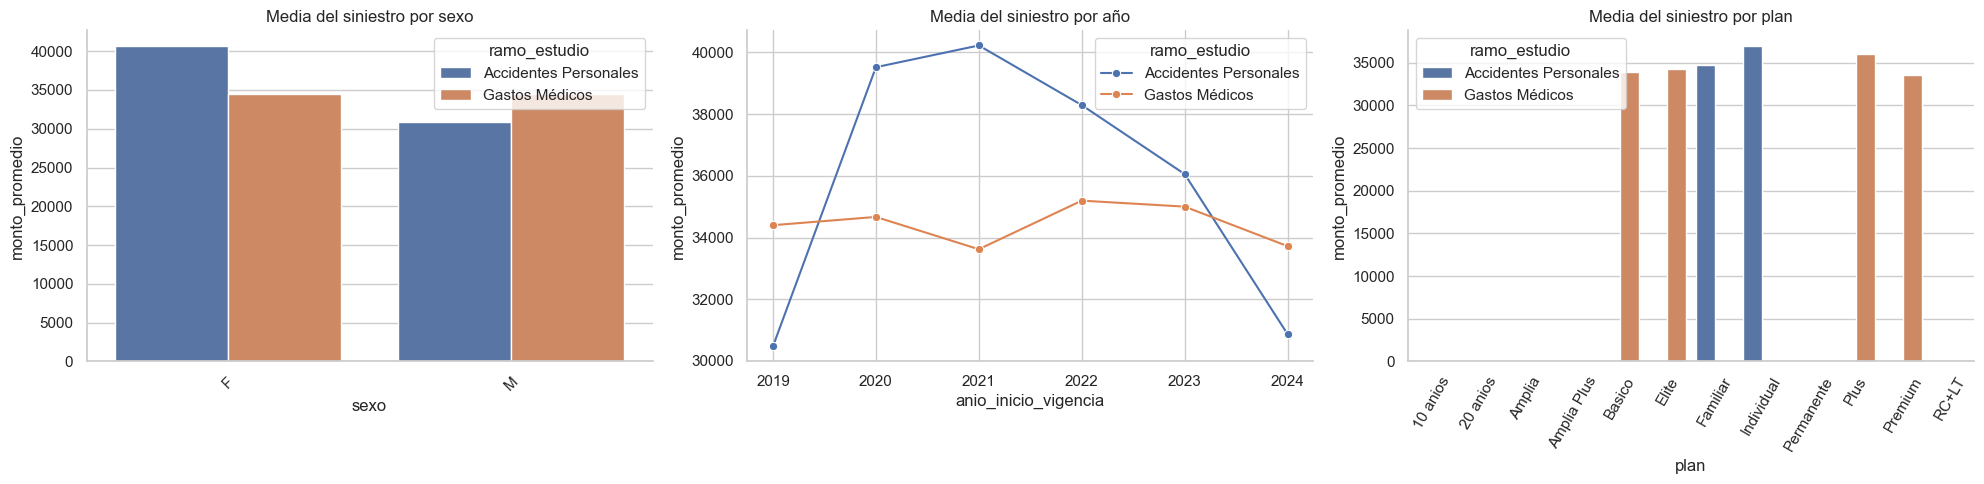

In [10]:
df_siniestros_media = df_estudio.loc[
    (df_estudio[n_siniestros_col].fillna(0) > 0) &
    (df_estudio[monto_siniestro_col].fillna(0) > 0)
].copy()

media_por_sexo = (
    df_siniestros_media
    .groupby(['ramo_estudio', sexo_col], observed=False)
    .agg(
        polizas_con_siniestro=(id_col, 'count'),
        siniestros=(n_siniestros_col, 'sum'),
        monto_promedio=(monto_siniestro_col, 'mean'),
        monto_mediano=(monto_siniestro_col, 'median')
    )
    .sort_index()
)

media_por_anio = (
    df_siniestros_media
    .groupby(['ramo_estudio', 'anio_inicio_vigencia'], observed=False)
    .agg(
        polizas_con_siniestro=(id_col, 'count'),
        siniestros=(n_siniestros_col, 'sum'),
        monto_promedio=(monto_siniestro_col, 'mean'),
        monto_mediano=(monto_siniestro_col, 'median')
    )
    .sort_index()
)

media_por_plan = (
    df_siniestros_media
    .groupby(['ramo_estudio', plan_col], observed=False)
    .agg(
        polizas_con_siniestro=(id_col, 'count'),
        siniestros=(n_siniestros_col, 'sum'),
        monto_promedio=(monto_siniestro_col, 'mean'),
        monto_mediano=(monto_siniestro_col, 'median')
    )
    .sort_values(['ramo_estudio', 'monto_promedio'], ascending=[True, False])
)

display(media_por_sexo.round(2))
display(media_por_anio.round(2))
display(media_por_plan.round(2))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=media_por_sexo.reset_index(), x=sexo_col, y='monto_promedio', hue='ramo_estudio', ax=axes[0])
axes[0].set_title('Media del siniestro por sexo')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=media_por_anio.reset_index(), x='anio_inicio_vigencia', y='monto_promedio', hue='ramo_estudio', marker='o', ax=axes[1])
axes[1].set_title('Media del siniestro por año')

top_planes = media_por_plan.reset_index().groupby('ramo_estudio').head(8)
sns.barplot(data=top_planes, x=plan_col, y='monto_promedio', hue='ramo_estudio', ax=axes[2])
axes[2].set_title('Media del siniestro por plan')
axes[2].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()


**MARCA_CONCLUSION_MEDIAS_SINIESTRO**

Estas tablas permiten ver si la severidad promedio cambia por sexo, año de inicio o plan. En seguros conviene comparar media y mediana juntas: si la media es mucho mayor que la mediana, el promedio está influido por pocos siniestros grandes. Para planes con pocas pólizas con siniestro, interpretaría la media con cautela.

## 10. Dataset transformado para uso posterior

In [11]:
columnas_salida = [
    id_col, 'ramo_estudio', sexo_col, edad_col, 'mayor_65',
    'anio_inicio_vigencia', plan_col, prima_col, n_siniestros_col,
    monto_siniestro_col
]

columnas_salida = [c for c in columnas_salida if c in df_modelo.columns]
df_tema2_modelo = pd.concat(
    [
        df_modelo[columnas_salida].reset_index(drop=True),
        df_modelo[columnas_codificadas].reset_index(drop=True),
        df_escalado[[c for c in df_escalado.columns if c.endswith(('z_score', 'min_max', 'robust'))]].reset_index(drop=True)
    ],
    axis=1
)

print(f'Dataset final Tema 2: {df_tema2_modelo.shape[0]:,} filas x {df_tema2_modelo.shape[1]:,} columnas')
display(df_tema2_modelo.head())


Dataset final Tema 2: 27,738 filas x 26 columnas


,id_poliza,ramo_estudio,sexo,edad,mayor_65,anio_inicio_vigencia,plan,prima_total,n_siniestros,monto_pagado,...,plan_Familiar,plan_Individual,plan_Plus,plan_Premium,prima_z_score,prima_min_max,prima_robust,siniestro_z_score,siniestro_min_max,siniestro_robust
0,POL-000003,Gastos Médicos,M,31,0,2022,Basico,"22,049.28",0.00,0.00,...,0,0,0,0,-0.19,0.17,0.26,-0.20,0.00,0.00
1,POL-000007,Gastos Médicos,M,58,0,2023,Plus,"32,410.40",0.00,0.00,...,0,0,1,0,0.19,0.26,0.65,-0.20,0.00,0.00
2,POL-000008,Gastos Médicos,M,54,0,2019,Plus,"6,484.63",0.00,0.00,...,0,0,1,0,-0.75,0.03,-0.32,-0.20,0.00,0.00
3,POL-000009,Gastos Médicos,M,32,0,2024,Elite,"76,560.00",0.00,0.00,...,0,0,0,0,1.77,0.66,2.31,-0.20,0.00,0.00
4,POL-000011,Gastos Médicos,F,40,0,2023,Premium,"20,416.00",1.00,"7,655.00",...,0,0,0,1,-0.25,0.16,0.20,0.15,0.01,"7,655.00"


**MARCA_CONCLUSION_FINAL**

El notebook deja una base transformada con variables originales, codificaciones, variables derivadas y escalamiento. Para un modelo predictivo, todavía revisaría fuga de información, partición train/test y selección de variables según el objetivo: frecuencia, severidad, prima o clasificación de siniestro.